# Exotic Option Pricing with Heston Model

This notebook demonstrates pricing of exotic options using Monte Carlo simulation under the calibrated Heston stochastic volatility model.

**Exotic Structures:**
1. **Digital Option (Binary)**: Pays 1 if $S_T > K$ at maturity $T$, 0 otherwise
2. **One-Touch Up Option**: Pays 1 when stock price touches barrier $B$ from below (anytime before maturity), then terminates

**Method:**
- Monte Carlo path simulation using calibrated Heston parameters
- Euler scheme with full truncation for variance process
- Path-dependent monitoring for barrier options

In [1]:
# Auto-reload modules during development
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
from typing import Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import time
import warnings
import torch
warnings.filterwarnings('ignore')

# Add project root to path
PROJECT_ROOT = Path("..")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.heston_model import HestonModel
from src.heston_model_neural_calibration import (
    load_surrogate,
    load_param_predictor,
    calibrate_heston_with_surrogate_optimization,
    predict_heston_params,
    extract_market_features,
)

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Load Calibrated Heston Parameters

Load calibrated Heston parameters from either classic or neural network calibration. We'll use these parameters for Monte Carlo simulation.


In [2]:
# Option 1: Load from saved calibration results (if available)
import json
import glob

results_dir = PROJECT_ROOT / 'data' / 'results'
calib_results_files = sorted(glob.glob(str(results_dir / 'calibration_results_*.json')))

if calib_results_files:
    latest_file = calib_results_files[-1]
    print(f"Loading calibration results from: {latest_file}")
    with open(latest_file, 'r') as f:
        calib_results = json.load(f)
    
    calibrated_params = calib_results.get('parameters', {})
    S0 = calib_results.get('spot_price', 100.0)
    r = calibrated_params.get('r', 0.04)
    
    print(f"Loaded calibrated parameters:")
    print(f"  Spot price: ${S0:.2f}")
    print(f"  Risk-free rate: {r*100:.2f}%")
else:
    # Option 2: Use example calibrated parameters (from classic calibration notebook)
    # Replace these with your actual calibrated parameters
    print("No saved calibration found. Using example parameters.")
    print("(Replace with your calibrated parameters from calibration notebooks)")
    
    calibrated_params = {
        'v0': 0.04,      # Initial variance
        'kappa': 2.0,    # Mean reversion speed
        'theta': 0.04,   # Long-term variance
        'sigma': 0.3,    # Volatility of volatility
        'rho': -0.7,     # Correlation
        'lambd': 0.0,    # Market price of risk
        'r': 0.04,       # Risk-free rate
        'q': 0.0         # Dividend yield
    }
    S0 = 100.0  # Example spot price

# Create Heston model with classic calibrated parameters
heston_model_classic = HestonModel(
    kappa=calibrated_params['kappa'],
    theta=calibrated_params['theta'],
    sigma=calibrated_params['sigma'],
    rho=calibrated_params['rho'],
    v0=calibrated_params['v0'],
    r=calibrated_params.get('r', 0.04),
    q=calibrated_params.get('q', 0.0),
    lambd=calibrated_params.get('lambd', 0.0)
)

print(f"\nClassic Heston Model Parameters:")
print(f"  κ (kappa):  {calibrated_params['kappa']:.4f}")
print(f"  θ (theta):  {calibrated_params['theta']:.4f}")
print(f"  σ (sigma):  {calibrated_params['sigma']:.4f}")
print(f"  ρ (rho):    {calibrated_params['rho']:.4f}")
print(f"  v₀:         {calibrated_params['v0']:.4f}")
print(f"  r:          {calibrated_params.get('r', 0.04):.4f}")
print(f"  S₀:         ${S0:.2f}")

# Keep reference for backward compatibility
heston_model = heston_model_classic

Loading calibration results from: ../data/results/calibration_results_20251121_144052.json
Loaded calibrated parameters:
  Spot price: $588.84
  Risk-free rate: 3.98%

Classic Heston Model Parameters:
  κ (kappa):  5.0000
  θ (theta):  0.0645
  σ (sigma):  0.5628
  ρ (rho):    -1.0000
  v₀:         0.0851
  r:          0.0398
  S₀:         $588.84


## 1.5. Load Neural Network Models and Calibrate

Load the trained neural network models and calibrate Heston parameters using the neural network approach.


In [4]:
# Load neural network models
MODELS_DIR = PROJECT_ROOT / "models" / "heston_nn"
SURROGATE_PATH = MODELS_DIR / "surrogate_pricing.pt"
PREDICTOR_PATH = MODELS_DIR / "market_param_predictor.pt"

print("Loading neural network models...")
try:
    surrogate = load_surrogate(SURROGATE_PATH, device=torch.device("cpu"))
    predictor = load_param_predictor(PREDICTOR_PATH, device=torch.device("cpu"))
    print(" Surrogate pricing network loaded")
    print(" Parameter predictor loaded")
    nn_models_available = True
except FileNotFoundError as e:
    print(f" Neural network models not found: {e}")
    print("  Skipping neural network calibration. Using classic calibration only.")
    nn_models_available = False
    surrogate = None
    predictor = None

Loading neural network models...
 Surrogate pricing network loaded
 Parameter predictor loaded


In [ ]:
# Calibrate using neural network (if models are available)
if nn_models_available:
    print("\n" + "="*70)
    print("NEURAL NETWORK CALIBRATION")
    print("="*70)
    
    # Try to load calibration data for NN calibration
    calibration_dir = PROJECT_ROOT / "data" / "processed" / "calibration_data"
    
    # Find most recent calibration file
    import glob
    import os
    calib_files = list(calibration_dir.glob("qqq_calibration_data_*.csv"))
    if calib_files:
        calib_data_path = sorted(calib_files, key=os.path.getmtime)[-1]
    else:
        calib_data_path = calibration_dir / "qqq_calibration_data_20251120_132056.csv"  # Fallback
    
    if calib_data_path.exists():
        print(f"Loading calibration data from: {calib_data_path}")
        calib_data = pd.read_csv(calib_data_path)
        
        # Extract market features and predict parameters
        print("Extracting market features...")
        features = extract_market_features(calib_data)
        
        # Direct prediction
        print("Performing direct parameter prediction...")
        nn_params_direct = predict_heston_params(features, predictor)
        
        # Optimization-based calibration
        print("Performing optimization-based calibration...")
        market_data = pd.DataFrame({
            'strike': calib_data['strike'].values,
            'tau': calib_data['tau'].values,
            'mid_price': calib_data['mid_price'].values,
            'r': calib_data['r'].values,
            'type': calib_data['type'].values,
            'spot': calib_data['spot'].values,
        })
        
        # Convert direct prediction to dict for initial guess
        initial_params_from_nn = np.array([
            nn_params_direct.v0,
            nn_params_direct.kappa,
            nn_params_direct.theta,
            nn_params_direct.sigma,
            nn_params_direct.rho,
            nn_params_direct.lambd,
        ], dtype=np.float32)
        
        nn_params_optimized = calibrate_heston_with_surrogate_optimization(
            market_prices=market_data,
            surrogate=surrogate,
            S0=S0,
            predictor=None,
            initial_params=initial_params_from_nn,
            method="L-BFGS-B",
            maxiter=500,
            use_relative_loss=True,
        )
        
        # Create Heston model with NN-optimized parameters
        heston_model_nn = HestonModel(
            kappa=nn_params_optimized['kappa'],
            theta=nn_params_optimized['theta'],
            sigma=nn_params_optimized['sigma'],
            rho=nn_params_optimized['rho'],
            v0=nn_params_optimized['v0'],
            r=calibrated_params.get('r', 0.04),
            q=calibrated_params.get('q', 0.0),
            lambd=nn_params_optimized['lambd']
        )
        
        print(f"\nNeural Network Optimized Parameters:")
        print(f"  κ (kappa):  {nn_params_optimized['kappa']:.4f}")
        print(f"  θ (theta):  {nn_params_optimized['theta']:.4f}")
        print(f"  σ (sigma):  {nn_params_optimized['sigma']:.4f}")
        print(f"  ρ (rho):    {nn_params_optimized['rho']:.4f}")
        print(f"  v₀:         {nn_params_optimized['v0']:.4f}")
        print(f"  λ (lambd):  {nn_params_optimized['lambd']:.4f}")
        
        nn_calibration_available = True
    else:
        print(f" Calibration data not found at: {calib_data_path}")
        print("  Using classic calibration parameters only.")
        nn_calibration_available = False
        heston_model_nn = None
else:
    nn_calibration_available = False
    heston_model_nn = None


NEURAL NETWORK CALIBRATION
Loading calibration data from: ../data/processed/qqq_calibration_data_20251120_132056.csv
Extracting market features...
Performing direct parameter prediction...
Performing optimization-based calibration...

Neural Network Optimized Parameters:
  κ (kappa):  8.0000
  θ (theta):  0.2500
  σ (sigma):  1.5000
  ρ (rho):    0.0000
  v₀:         0.2500
  λ (lambd):  0.5000


## 2. Digital Option (Binary Option)

### Theory

A **digital option** (also called binary option) pays a fixed amount if a condition is met at maturity, otherwise pays nothing.

**Payoff:**
$$
\text{Payoff} = \begin{cases}
1 & \text{if } S_T > K \\
0 & \text{if } S_T \leq K
\end{cases}
$$

where:
- $S_T$ = stock price at maturity $T$
- $K$ = strike/barrier level

**Pricing Formula:**

Under risk-neutral measure, the price is:
$$
V_{\text{digital}}(S_0, K, T) = e^{-rT} \mathbb{E}^Q[\mathbf{1}_{S_T > K}]
$$

where $\mathbf{1}_{S_T > K}$ is the indicator function.

**Monte Carlo Estimation:**

$$
V_{\text{digital}} \approx e^{-rT} \frac{1}{N} \sum_{i=1}^N \mathbf{1}_{S_T^{(i)} > K}
$$

where $S_T^{(i)}$ are simulated terminal prices from $N$ Monte Carlo paths.

**Standard Error:**

$$
\text{SE} = e^{-rT} \sqrt{\frac{p(1-p)}{N}}
$$

where $p = \frac{1}{N}\sum_{i=1}^N \mathbf{1}_{S_T^{(i)} > K}$ is the probability estimate.

In [6]:
def price_digital_option(model: HestonModel, S0: float, K: float, T: float,
                         n_paths: int = 100000, n_steps: int = 252, seed: Optional[int] = None) -> dict:
    """
    Price a digital option using Monte Carlo simulation.
    
    Args:
        model: HestonModel instance with calibrated parameters
        S0: Initial stock price
        K: Strike/barrier level
        T: Time to maturity (years)
        n_paths: Number of Monte Carlo paths
        n_steps: Number of time steps per path
        seed: Random seed for reproducibility
        
    Returns:
        Dictionary with price, standard error, and statistics
    """
    # Simulate paths
    times, spot_paths, var_paths = model.simulate_paths(
        S0, T, n_steps, n_paths, seed=seed, full_truncation=True
    )
    
    # Terminal prices
    terminal_prices = spot_paths[:, -1]
    
    # Payoff: 1 if S_T > K, 0 otherwise
    payoffs = (terminal_prices > K).astype(float)
    
    # Discount to present value
    price = np.exp(-model.r * T) * np.mean(payoffs)
    
    # Standard error
    p_hat = np.mean(payoffs)
    std_error = np.exp(-model.r * T) * np.sqrt(p_hat * (1 - p_hat) / n_paths)
    
    # Statistics
    prob_above = p_hat
    prob_below = 1 - p_hat
    
    return {
        'price': price,
        'std_error': std_error,
        'prob_above_barrier': prob_above,
        'prob_below_barrier': prob_below,
        'terminal_prices': terminal_prices,
        'payoffs': payoffs
    }

# Example: Price a digital option
print("Digital Option Pricing Example")
print("="*70)

K_digital = S0 * 1.1  # 10% above current spot
T_digital = 0.5  # 6 months

print(f"Parameters:")
print(f"  Strike (K): ${K_digital:.2f}")
print(f"  Maturity (T): {T_digital:.2f} years")
print(f"  Spot (S₀): ${S0:.2f}")

# Price with classic calibration
print(f"\n{'='*70}")
print("Classic Calibration Pricing")
print("="*70)
print(f"Running Monte Carlo simulation...")

start_time = time.time()
digital_result_classic = price_digital_option(
    model=heston_model_classic,
    S0=S0,
    K=K_digital,
    T=T_digital,
    n_paths=100000,
    n_steps=252,
    seed=42
)
pricing_time_classic = time.time() - start_time

print(f"Simulation complete in {pricing_time_classic:.2f} seconds")
print(f"\nResults (Classic):")
print(f"  Digital Option Price: ${digital_result_classic['price']:.6f}")
print(f"  Standard Error:       ${digital_result_classic['std_error']:.6f}")
print(f"  95% Confidence:       [${digital_result_classic['price'] - 1.96*digital_result_classic['std_error']:.6f}, ${digital_result_classic['price'] + 1.96*digital_result_classic['std_error']:.6f}]")
print(f"\nProbability Statistics:")
print(f"  P(S_T > K): {digital_result_classic['prob_above_barrier']:.4f} ({digital_result_classic['prob_above_barrier']*100:.2f}%)")
print(f"  P(S_T ≤ K): {digital_result_classic['prob_below_barrier']:.4f} ({digital_result_classic['prob_below_barrier']*100:.2f}%)")

# Price with neural network calibration (if available)
if nn_calibration_available:
    print(f"\n{'='*70}")
    print("Neural Network Calibration Pricing")
    print("="*70)
    print(f"Running Monte Carlo simulation...")
    
    start_time = time.time()
    digital_result_nn = price_digital_option(
        model=heston_model_nn,
        S0=S0,
        K=K_digital,
        T=T_digital,
        n_paths=100000,
        n_steps=252,
        seed=42
    )
    pricing_time_nn = time.time() - start_time
    
    print(f"Simulation complete in {pricing_time_nn:.2f} seconds")
    print(f"\nResults (Neural Network):")
    print(f"  Digital Option Price: ${digital_result_nn['price']:.6f}")
    print(f"  Standard Error:       ${digital_result_nn['std_error']:.6f}")
    print(f"  95% Confidence:       [${digital_result_nn['price'] - 1.96*digital_result_nn['std_error']:.6f}, ${digital_result_nn['price'] + 1.96*digital_result_nn['std_error']:.6f}]")
    print(f"\nProbability Statistics:")
    print(f"  P(S_T > K): {digital_result_nn['prob_above_barrier']:.4f} ({digital_result_nn['prob_above_barrier']*100:.2f}%)")
    print(f"  P(S_T ≤ K): {digital_result_nn['prob_below_barrier']:.4f} ({digital_result_nn['prob_below_barrier']*100:.2f}%)")
    
    # Comparison
    print(f"\n{'='*70}")
    print("Comparison")
    print("="*70)
    price_diff = digital_result_nn['price'] - digital_result_classic['price']
    price_diff_pct = (price_diff / digital_result_classic['price']) * 100
    print(f"Price difference: ${price_diff:.6f} ({price_diff_pct:+.2f}%)")
    print(f"Classic:  ${digital_result_classic['price']:.6f} ± ${digital_result_classic['std_error']:.6f}")
    print(f"NN:       ${digital_result_nn['price']:.6f} ± ${digital_result_nn['std_error']:.6f}")

# Keep reference for backward compatibility
digital_result = digital_result_classic

Digital Option Pricing Example
Parameters:
  Strike (K): $647.72
  Maturity (T): 0.50 years
  Spot (S₀): $588.84

Classic Calibration Pricing
Running Monte Carlo simulation...
Simulation complete in 2.39 seconds

Results (Classic):
  Digital Option Price: $0.364052
  Standard Error:       $0.001498
  95% Confidence:       [$0.361117, $0.366988]

Probability Statistics:
  P(S_T > K): 0.3714 (37.14%)
  P(S_T ≤ K): 0.6286 (62.86%)

Neural Network Calibration Pricing
Running Monte Carlo simulation...
Simulation complete in 1.51 seconds

Results (Neural Network):
  Digital Option Price: $0.339300
  Standard Error:       $0.001475
  95% Confidence:       [$0.336409, $0.342190]

Probability Statistics:
  P(S_T > K): 0.3461 (34.61%)
  P(S_T ≤ K): 0.6539 (65.39%)

Comparison
Price difference: $-0.024752 (-6.80%)
Classic:  $0.364052 ± $0.001498
NN:       $0.339300 ± $0.001475


## 3. One-Touch Up Option

### Theory

A **one-touch up option** pays a fixed amount (typically 1) when the underlying asset price touches a barrier level from below, and the product terminates immediately.

**Payoff:**
$$
\text{Payoff} = \begin{cases}
1 & \text{if } \exists t \in [0, T] \text{ such that } S_t \geq B \text{ and } S_0 < B \\
0 & \text{otherwise}
\end{cases}
$$

where:
- $B$ = barrier level (above initial spot)
- $S_t$ = stock price at time $t$
- $T$ = maturity

**Key Characteristics:**
- **Path-dependent**: Requires monitoring the entire price path
- **Early termination**: Option expires immediately when barrier is touched
- **Up-and-out**: Barrier is above initial spot ($B > S_0$)

**Pricing Formula:**

Under risk-neutral measure:
$$
V_{\text{one-touch}}(S_0, B, T) = e^{-r\tau} \mathbb{E}^Q[\mathbf{1}_{\tau \leq T}]
$$

where $\tau = \inf\{t \geq 0 : S_t \geq B\}$ is the **first hitting time** of the barrier.

**Monte Carlo Estimation:**

For each path $i$, check if barrier is touched:
$$
\text{Payoff}^{(i)} = \begin{cases}
e^{-r\tau^{(i)}} & \text{if } \tau^{(i)} \leq T \\
0 & \text{if barrier never touched}
\end{cases}
$$

Then:
$$
V_{\text{one-touch}} \approx \frac{1}{N} \sum_{i=1}^N \text{Payoff}^{(i)}
$$

**Discrete Monitoring:**

In practice, we monitor at discrete time steps:
$$
\text{Payoff}^{(i)} = \begin{cases}
e^{-r t_k} & \text{if } S_{t_k}^{(i)} \geq B \text{ for some } k \in \{1, \ldots, n\} \\
0 & \text{otherwise}
\end{cases}
$$

where $t_k = k \cdot \Delta t$ and $\Delta t = T/n$.

In [8]:
def price_one_touch_up(model: HestonModel, S0: float, B: float, T: float,
                       n_paths: int = 100000, n_steps: int = 252, seed: Optional[int] = None) -> dict:
    """
    Price a one-touch up option using Monte Carlo simulation.
    
    The option pays 1 when stock price touches barrier B from below (anytime before maturity).
    
    Args:
        model: HestonModel instance with calibrated parameters
        S0: Initial stock price (must be < B)
        B: Barrier level (must be > S0)
        T: Time to maturity (years)
        n_paths: Number of Monte Carlo paths
        n_steps: Number of time steps per path
        seed: Random seed for reproducibility
        
    Returns:
        Dictionary with price, standard error, and statistics
    """
    if S0 >= B:
        raise ValueError(f"Barrier B={B} must be above initial spot S0={S0}")
    
    # Simulate paths
    times, spot_paths, var_paths = model.simulate_paths(
        S0, T, n_steps, n_paths, seed=seed, full_truncation=True
    )
    
    # Check if barrier is touched for each path
    # For each path, find first time barrier is crossed
    payoffs = np.zeros(n_paths)
    hitting_times = np.full(n_paths, np.nan)
    
    for i in range(n_paths):
        path = spot_paths[i, :]
        # Find first index where path >= barrier
        hit_indices = np.where(path >= B)[0]
        
        if len(hit_indices) > 0:
            # Barrier was touched
            first_hit_idx = hit_indices[0]
            hitting_time = times[first_hit_idx]
            hitting_times[i] = hitting_time
            
            # Payoff: 1 discounted to hitting time
            payoffs[i] = np.exp(-model.r * hitting_time)
        else:
            # Barrier never touched
            payoffs[i] = 0.0
    
    # Price is average payoff
    price = np.mean(payoffs)
    
    # Standard error
    std_error = np.std(payoffs) / np.sqrt(n_paths)
    
    # Statistics
    prob_touch = np.sum(payoffs > 0) / n_paths
    prob_no_touch = 1 - prob_touch
    
    # Average hitting time (for paths that hit)
    avg_hitting_time = np.nanmean(hitting_times)
    
    return {
        'price': price,
        'std_error': std_error,
        'prob_touch': prob_touch,
        'prob_no_touch': prob_no_touch,
        'avg_hitting_time': avg_hitting_time,
        'hitting_times': hitting_times,
        'payoffs': payoffs,
        'spot_paths': spot_paths,
        'times': times
    }

# Example: Price a one-touch up option
print("\n" + "="*70)
print("One-Touch Up Option Pricing Example")
print("="*70)

B_touch = S0 * 1.1  # 10% above current spot
T_touch = 0.5  # 6 months

print(f"Parameters:")
print(f"  Barrier (B): ${B_touch:.2f}")
print(f"  Maturity (T): {T_touch:.2f} years")
print(f"  Spot (S₀): ${S0:.2f}")
print(f"  Barrier is {((B_touch/S0 - 1)*100):.1f}% above spot")

# Price with classic calibration
print(f"\n{'='*70}")
print("Classic Calibration Pricing")
print("="*70)
print(f"Running Monte Carlo simulation...")

start_time = time.time()
touch_result_classic = price_one_touch_up(
    model=heston_model_classic,
    S0=S0,
    B=B_touch,
    T=T_touch,
    n_paths=100000,
    n_steps=252,
    seed=42
)
pricing_time_classic = time.time() - start_time

print(f"Simulation complete in {pricing_time_classic:.2f} seconds")
print(f"\nResults (Classic):")
print(f"  One-Touch Up Price: ${touch_result_classic['price']:.6f}")
print(f"  Standard Error:     ${touch_result_classic['std_error']:.6f}")
print(f"  95% Confidence:     [${touch_result_classic['price'] - 1.96*touch_result_classic['std_error']:.6f}, ${touch_result_classic['price'] + 1.96*touch_result_classic['std_error']:.6f}]")
print(f"\nProbability Statistics:")
print(f"  P(Barrier touched): {touch_result_classic['prob_touch']:.4f} ({touch_result_classic['prob_touch']*100:.2f}%)")
print(f"  P(Barrier not touched): {touch_result_classic['prob_no_touch']:.4f} ({touch_result_classic['prob_no_touch']*100:.2f}%)")
if not np.isnan(touch_result_classic['avg_hitting_time']):
    print(f"  Average hitting time: {touch_result_classic['avg_hitting_time']:.4f} years ({touch_result_classic['avg_hitting_time']*365:.1f} days)")

# Price with neural network calibration (if available)
if nn_calibration_available:
    print(f"\n{'='*70}")
    print("Neural Network Calibration Pricing")
    print("="*70)
    print(f"Running Monte Carlo simulation...")
    
    start_time = time.time()
    touch_result_nn = price_one_touch_up(
        model=heston_model_nn,
        S0=S0,
        B=B_touch,
        T=T_touch,
        n_paths=100000,
        n_steps=252,
        seed=42
    )
    pricing_time_nn = time.time() - start_time
    
    print(f"Simulation complete in {pricing_time_nn:.2f} seconds")
    print(f"\nResults (Neural Network):")
    print(f"  One-Touch Up Price: ${touch_result_nn['price']:.6f}")
    print(f"  Standard Error:     ${touch_result_nn['std_error']:.6f}")
    print(f"  95% Confidence:     [${touch_result_nn['price'] - 1.96*touch_result_nn['std_error']:.6f}, ${touch_result_nn['price'] + 1.96*touch_result_nn['std_error']:.6f}]")
    print(f"\nProbability Statistics:")
    print(f"  P(Barrier touched): {touch_result_nn['prob_touch']:.4f} ({touch_result_nn['prob_touch']*100:.2f}%)")
    print(f"  P(Barrier not touched): {touch_result_nn['prob_no_touch']:.4f} ({touch_result_nn['prob_no_touch']*100:.2f}%)")
    if not np.isnan(touch_result_nn['avg_hitting_time']):
        print(f"  Average hitting time: {touch_result_nn['avg_hitting_time']:.4f} years ({touch_result_nn['avg_hitting_time']*365:.1f} days)")
    
    # Comparison
    print(f"\n{'='*70}")
    print("Comparison")
    print("="*70)
    price_diff = touch_result_nn['price'] - touch_result_classic['price']
    price_diff_pct = (price_diff / touch_result_classic['price']) * 100
    print(f"Price difference: ${price_diff:.6f} ({price_diff_pct:+.2f}%)")
    print(f"Classic:  ${touch_result_classic['price']:.6f} ± ${touch_result_classic['std_error']:.6f}")
    print(f"NN:       ${touch_result_nn['price']:.6f} ± ${touch_result_nn['std_error']:.6f}")
    
    # Compare hitting probabilities
    prob_diff = touch_result_nn['prob_touch'] - touch_result_classic['prob_touch']
    print(f"\nHitting probability difference: {prob_diff:.4f} ({prob_diff*100:+.2f} percentage points)")
    print(f"  Classic: {touch_result_classic['prob_touch']:.4f} ({touch_result_classic['prob_touch']*100:.2f}%)")
    print(f"  NN:      {touch_result_nn['prob_touch']:.4f} ({touch_result_nn['prob_touch']*100:.2f}%)")

# Keep reference for backward compatibility
touch_result = touch_result_classic


One-Touch Up Option Pricing Example
Parameters:
  Barrier (B): $647.72
  Maturity (T): 0.50 years
  Spot (S₀): $588.84
  Barrier is 10.0% above spot

Classic Calibration Pricing
Running Monte Carlo simulation...
Simulation complete in 1.67 seconds

Results (Classic):
  One-Touch Up Price: $0.594385
  Standard Error:     $0.001540
  95% Confidence:     [$0.591368, $0.597403]

Probability Statistics:
  P(Barrier touched): 0.5985 (59.85%)
  P(Barrier not touched): 0.4015 (40.15%)
  Average hitting time: 0.1740 years (63.5 days)

Neural Network Calibration Pricing
Running Monte Carlo simulation...
Simulation complete in 1.90 seconds

Results (Neural Network):
  One-Touch Up Price: $0.716214
  Standard Error:     $0.001415
  95% Confidence:     [$0.713441, $0.718987]

Probability Statistics:
  P(Barrier touched): 0.7194 (71.94%)
  P(Barrier not touched): 0.2806 (28.06%)
  Average hitting time: 0.1114 years (40.7 days)

Comparison
Price difference: $0.121829 (+20.50%)
Classic:  $0.594385 ± 

## 4. Visualization: Digital Option

Visualize the Monte Carlo simulation results for the digital option.

Computing price sensitivity to strike...


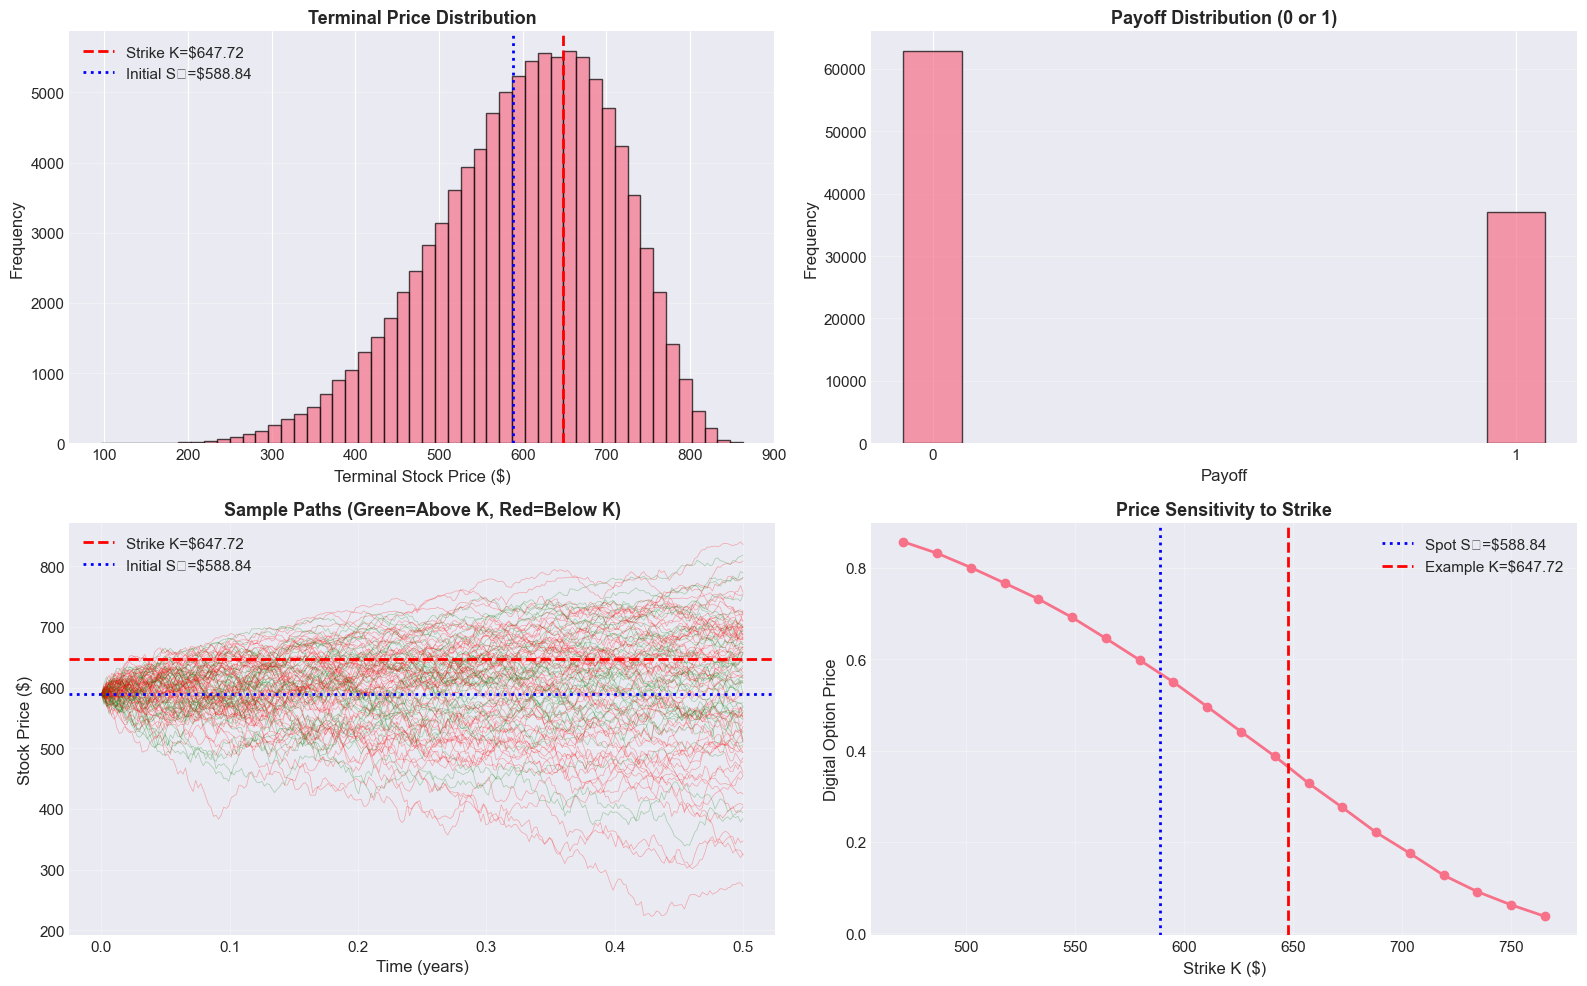


Digital option visualization complete


In [9]:
if 'digital_result' in locals():
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # 1. Terminal price distribution
    ax = axes[0, 0]
    ax.hist(digital_result['terminal_prices'], bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(K_digital, color='red', linestyle='--', linewidth=2, label=f'Strike K=${K_digital:.2f}')
    ax.axvline(S0, color='blue', linestyle=':', linewidth=2, label=f'Initial S₀=${S0:.2f}')
    ax.set_xlabel('Terminal Stock Price ($)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Terminal Price Distribution', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # 2. Payoff distribution
    ax = axes[0, 1]
    payoff_counts = pd.Series(digital_result['payoffs']).value_counts().sort_index()
    ax.bar(payoff_counts.index, payoff_counts.values, alpha=0.7, edgecolor='black', width=0.1)
    ax.set_xlabel('Payoff', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Payoff Distribution (0 or 1)', fontsize=13, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.grid(True, alpha=0.3, axis='y')
    
    # 3. Sample paths (showing paths that finish above/below barrier)
    ax = axes[1, 0]
    # Sample some paths
    n_show = 100
    sample_indices = np.random.choice(len(digital_result['terminal_prices']), n_show, replace=False)
    
    # Simulate paths again for visualization (or use stored paths if available)
    times_viz, spot_paths_viz, _ = heston_model.simulate_paths(
        S0, T_digital, 252, n_show, seed=123
    )
    
    for i, idx in enumerate(sample_indices):
        terminal_price = digital_result['terminal_prices'][idx]
        if terminal_price > K_digital:
            color = 'green'
            alpha = 0.3
        else:
            color = 'red'
            alpha = 0.3
        ax.plot(times_viz, spot_paths_viz[i], color=color, alpha=alpha, linewidth=0.5)
    
    ax.axhline(K_digital, color='red', linestyle='--', linewidth=2, label=f'Strike K=${K_digital:.2f}')
    ax.axhline(S0, color='blue', linestyle=':', linewidth=2, label=f'Initial S₀=${S0:.2f}')
    ax.set_xlabel('Time (years)', fontsize=12)
    ax.set_ylabel('Stock Price ($)', fontsize=12)
    ax.set_title(f'Sample Paths (Green=Above K, Red=Below K)', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Price sensitivity to strike
    ax = axes[1, 1]
    strikes_test = np.linspace(S0 * 0.8, S0 * 1.3, 20)
    prices_test = []
    
    print("Computing price sensitivity to strike...")
    for K_test in strikes_test:
        result_test = price_digital_option(
            model=heston_model,
            S0=S0,
            K=K_test,
            T=T_digital,
            n_paths=50000,  # Fewer paths for speed
            n_steps=252,
            seed=None
        )
        prices_test.append(result_test['price'])
    
    ax.plot(strikes_test, prices_test, 'o-', linewidth=2, markersize=6)
    ax.axvline(S0, color='blue', linestyle=':', linewidth=2, label=f'Spot S₀=${S0:.2f}')
    ax.axvline(K_digital, color='red', linestyle='--', linewidth=2, label=f'Example K=${K_digital:.2f}')
    ax.set_xlabel('Strike K ($)', fontsize=12)
    ax.set_ylabel('Digital Option Price', fontsize=12)
    ax.set_title('Price Sensitivity to Strike', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nDigital option visualization complete")
else:
    print("Run digital option pricing first")

## 5. Visualization: One-Touch Up Option

Visualize the Monte Carlo simulation results for the one-touch up option, showing paths that hit the barrier and those that don't.

Computing price sensitivity to barrier level...


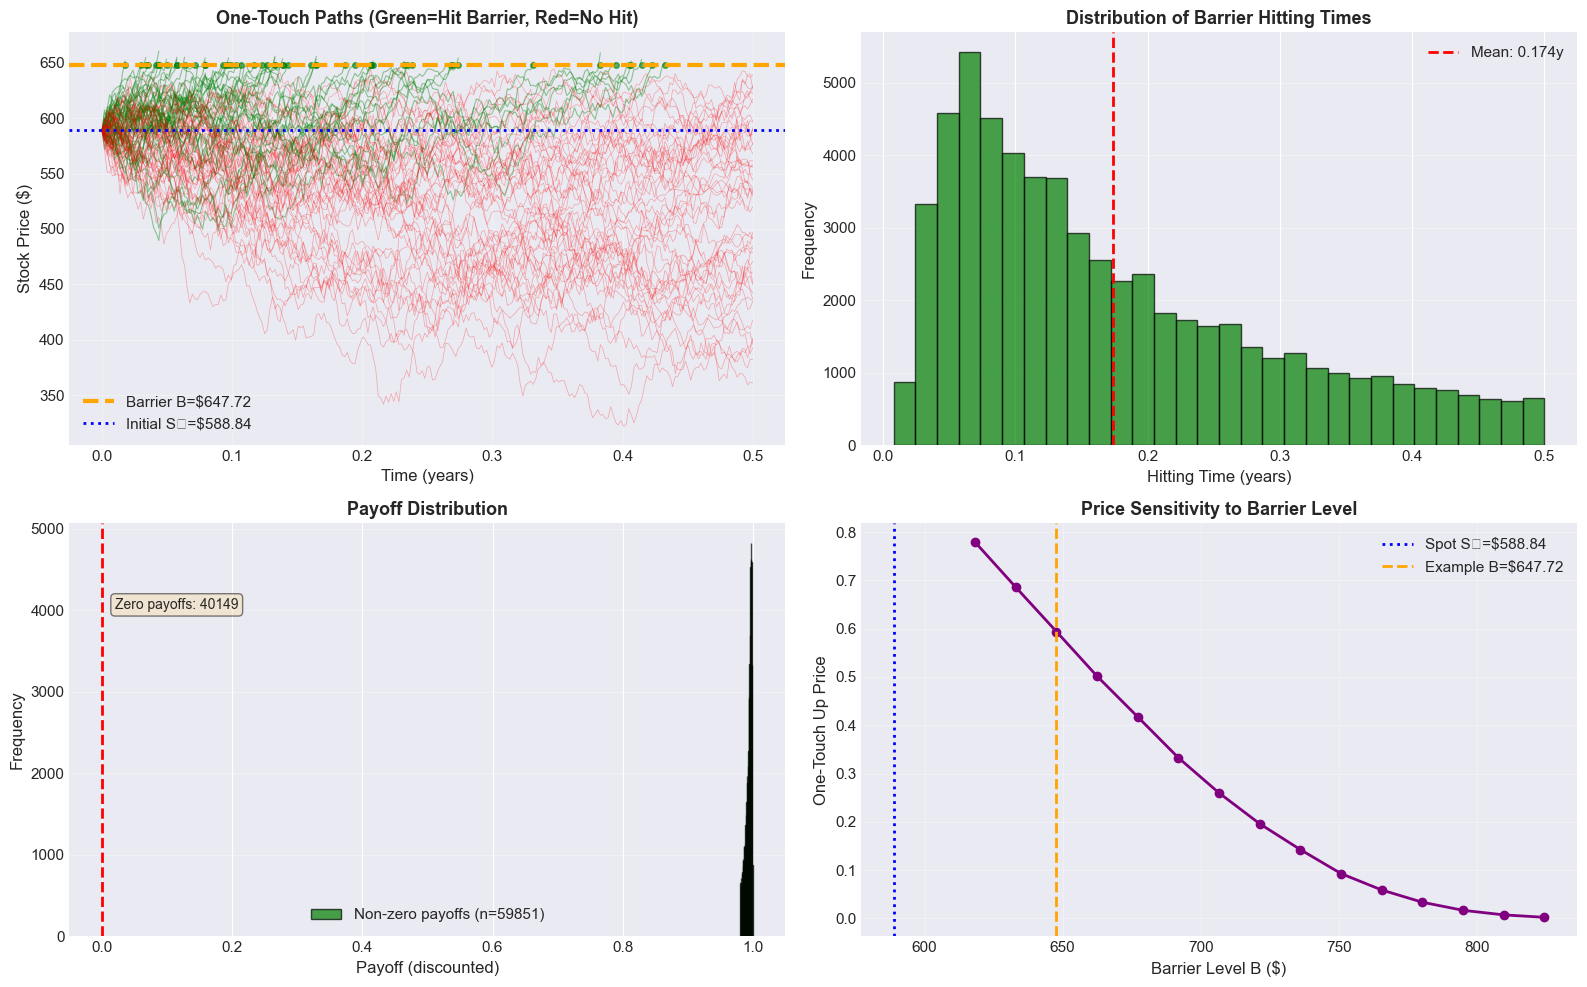


One-touch up option visualization complete


In [6]:
if 'touch_result' in locals():
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # 1. Sample paths: those that hit barrier vs those that don't
    ax = axes[0, 0]
    n_show = 200
    sample_indices = np.random.choice(len(touch_result['spot_paths']), n_show, replace=False)
    
    hit_paths = []
    no_hit_paths = []
    
    for idx in sample_indices:
        if touch_result['payoffs'][idx] > 0:
            hit_paths.append(idx)
        else:
            no_hit_paths.append(idx)
    
    # Plot paths that hit barrier (in green, stop at hitting time)
    for idx in hit_paths[:50]:  # Show up to 50 hitting paths
        path = touch_result['spot_paths'][idx]
        hit_time = touch_result['hitting_times'][idx]
        hit_idx = np.where(touch_result['times'] <= hit_time)[0][-1]
        ax.plot(touch_result['times'][:hit_idx+1], path[:hit_idx+1], 
               color='green', alpha=0.4, linewidth=0.8)
        # Mark hitting point
        ax.plot(hit_time, B_touch, 'go', markersize=4, alpha=0.6)
    
    # Plot paths that don't hit barrier (in red)
    for idx in no_hit_paths[:50]:  # Show up to 50 non-hitting paths
        ax.plot(touch_result['times'], touch_result['spot_paths'][idx], 
               color='red', alpha=0.3, linewidth=0.5)
    
    ax.axhline(B_touch, color='orange', linestyle='--', linewidth=3, label=f'Barrier B=${B_touch:.2f}')
    ax.axhline(S0, color='blue', linestyle=':', linewidth=2, label=f'Initial S₀=${S0:.2f}')
    ax.set_xlabel('Time (years)', fontsize=12)
    ax.set_ylabel('Stock Price ($)', fontsize=12)
    ax.set_title(f'One-Touch Paths (Green=Hit Barrier, Red=No Hit)', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Hitting time distribution (for paths that hit)
    ax = axes[0, 1]
    hitting_times_valid = touch_result['hitting_times'][~np.isnan(touch_result['hitting_times'])]
    if len(hitting_times_valid) > 0:
        ax.hist(hitting_times_valid, bins=30, alpha=0.7, edgecolor='black', color='green')
        ax.axvline(touch_result['avg_hitting_time'], color='red', linestyle='--', 
                  linewidth=2, label=f'Mean: {touch_result["avg_hitting_time"]:.3f}y')
        ax.set_xlabel('Hitting Time (years)', fontsize=12)
        ax.set_ylabel('Frequency', fontsize=12)
        ax.set_title('Distribution of Barrier Hitting Times', fontsize=13, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
    else:
        ax.text(0.5, 0.5, 'No paths hit the barrier', 
               ha='center', va='center', fontsize=14, transform=ax.transAxes)
        ax.set_title('Distribution of Barrier Hitting Times', fontsize=13, fontweight='bold')
    
    # 3. Payoff distribution
    ax = axes[1, 0]
    # Payoffs are either 0 or some discounted value
    nonzero_payoffs = touch_result['payoffs'][touch_result['payoffs'] > 0]
    zero_count = np.sum(touch_result['payoffs'] == 0)
    
    if len(nonzero_payoffs) > 0:
        ax.hist(nonzero_payoffs, bins=30, alpha=0.7, edgecolor='black', color='green', 
               label=f'Non-zero payoffs (n={len(nonzero_payoffs)})')
        ax.axvline(0, color='red', linestyle='--', linewidth=2)
        ax.text(0.02, zero_count/10, f'Zero payoffs: {zero_count}', 
               fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    else:
        ax.text(0.5, 0.5, f'All payoffs are zero\n(No paths hit barrier)', 
               ha='center', va='center', fontsize=14, transform=ax.transAxes)
    
    ax.set_xlabel('Payoff (discounted)', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Payoff Distribution', fontsize=13, fontweight='bold')
    if len(nonzero_payoffs) > 0:
        ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # 4. Price sensitivity to barrier level
    ax = axes[1, 1]
    barriers_test = np.linspace(S0 * 1.05, S0 * 1.4, 15)
    prices_test = []
    
    print("Computing price sensitivity to barrier level...")
    for B_test in barriers_test:
        result_test = price_one_touch_up(
            model=heston_model,
            S0=S0,
            B=B_test,
            T=T_touch,
            n_paths=50000,  # Fewer paths for speed
            n_steps=252,
            seed=None
        )
        prices_test.append(result_test['price'])
    
    ax.plot(barriers_test, prices_test, 'o-', linewidth=2, markersize=6, color='purple')
    ax.axvline(S0, color='blue', linestyle=':', linewidth=2, label=f'Spot S₀=${S0:.2f}')
    ax.axvline(B_touch, color='orange', linestyle='--', linewidth=2, label=f'Example B=${B_touch:.2f}')
    ax.set_xlabel('Barrier Level B ($)', fontsize=12)
    ax.set_ylabel('One-Touch Up Price', fontsize=12)
    ax.set_title('Price Sensitivity to Barrier Level', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nOne-touch up option visualization complete")
else:
    print("Run one-touch up option pricing first")